In [2]:
%load_ext autoreload
%autoreload 2

import util as yu
from util import *
import util_moments as yum
import util_charge as yuc

projs=['P0', 'Px', 'Py', 'Pz']
inserts=['tt', 'tx', 'ty', 'tz', 'xx', 'xy', 'xz', 'yy', 'yz', 'zz']
enss=['b','c','d','e']

In [15]:
ens='d'

path=f'/p/project1/ngff/li47/code/projectData/05_moments/cD211.054.96/data_merge/disc_2pt_vevsub.h5'
with h5py.File(path) as f:
    moms=[list(m) for m in f['moms'][:]]
    td='data'
    t=(f[f'{td}/N1_N1'][:]+f[f'{td}/N2_N2'][:])/2
    c2pt_fw=yu.jackknife(t)
    td='data_bw'
    t=(f[f'{td}/N1_N1'][:]+f[f'{td}/N2_N2'][:])/2
    c2pt_bw=yu.jackknife(t)
    
path=f'/p/project1/ngff/li47/code/scratch/run/05_moments_run5_1DV/cD211.054.96/data_merge_avgsrc/disc_0,0,1,0,0,0.h5'
js=['j+;disc']
key2tf2c3pt_fw={j:{} for j in js}
with h5py.File(path) as f:
    moms3=[list(m) for m in f['moms'][:]]
    for jtf in f['data'].keys():
        j,tf=jtf.split('_'); tf=int(tf)
        if j not in js:
            continue
        t=f[f'data/{jtf}'][:]
        key2tf2c3pt_fw[j][tf]=yu.jackknife(t)

In [14]:
key2vev={}
for ens in enss:
    path=f'/p/project1/ngff/li47/code/projectData/05_moments/{yu.ens2full[ens]}/data_merge/disc_jvev.h5'
    with h5py.File(path) as f:
        for j in js:
            t=f[j][:]
            key2vev[(ens,j)]=yu.jackknife(t)

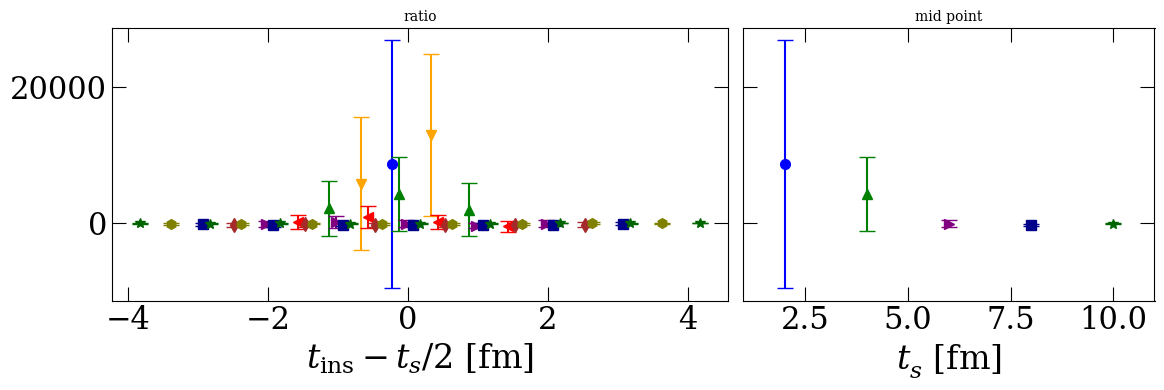

In [39]:
j='j+;disc'
tf2c3pt=key2tf2c3pt_fw[j]
tf2ratio={}
for tf in tf2c3pt.keys():
    c3pt=tf2c3pt[tf][:,:,moms3.index([0,0,1,0,0,0]),projs.index('P0'),inserts.index('tz')]
    c2pt=c2pt_fw[:,tf:tf+1,moms.index([0,0,1]),projs.index('P0')]
    vev= key2vev[(ens,j)][:,inserts.index('tz')][:,None]
    # print(vev.shape)
    ratio=c3pt/c2pt
    
    tf2ratio[tf]=np.imag(ratio)
    
yu.makePlot_3pt_rainbow(tf2ratio,tfmax=10)
yu.finalizePlot()

In [ ]:
enss=['d']
ens='d'

ens2c2pt={}; ens2moms_2pt={}; ens2c2pt0={}; ens2Njk={}
ens2c2pt_complex={}
for ens in enss:
    basepath=f'/p/project1/ngff/li47/code/projectData/05_moments/{yu.ens2full[ens]}/data_merge/'
    path=f'{basepath}disc_2pt.h5'
    with h5py.File(path) as f:
        moms_2pt=yu.moms2list(f['moms'])
        c2pt=yu.jackknife(np.real(f['data/N_N'][:,:,:]))
        c2pt_complex=yu.jackknife(f['data/N_N'][:,:,:])
        
    ens2moms_2pt[ens]=moms_2pt
    ens2c2pt[ens]=c2pt
    ens2c2pt0[ens]=c2pt[:,:,moms_2pt.index([0,0,0])]
    ens2c2pt_complex[ens]=c2pt_complex
    ens2Njk[ens]=len(c2pt)

projs=['P0', 'Px', 'Py', 'Pz']
inserts=['tt', 'tx', 'ty', 'tz', 'xx', 'xy', 'xz', 'yy', 'yz', 'zz']

stouts=[10]
# stouts=range(0,41)
js=['j+;disc','js;disc','jc;disc']+[f'jg;stout{stout}' for stout in stouts]

key2vev={}
for ens in enss:
    path=f'/p/project1/ngff/li47/code/projectData/05_moments/{yu.ens2full[ens]}/data_merge/disc_jvev.h5'
    with h5py.File(path) as f:
        for j in js:
            t=f[j][:]
            key2vev[(ens,j)]=yu.jackknife(t)

key2tf2ratio={}
key2tf2ratio_vevsub={}
for ens in enss:
    path=f'/p/project1/ngff/li47/code/scratch/run/05_moments_run5_1DV/{yu.ens2full[ens]}/data_merge/disc_0,0,1,0,0,0.h5'
    with h5py.File(path) as f:
        for jtf in f['data'].keys():
            j,tf=jtf.split('_'); tf=int(tf)
            if j not in js:
                continue        
            key=(ens,j)
            if key not in key2tf2ratio:
                key2tf2ratio[key]={}
                key2tf2ratio_vevsub[key]={}
            c3pt=yu.jackknife(f['data'][jtf][:,:,0,projs.index('P0'),inserts.index('tz')])
            c2pt=ens2c2pt[ens][:,tf,ens2moms_2pt[ens].index([0,0,1])]
            
            c2pt_complex=ens2c2pt_complex[ens][:,tf,ens2moms_2pt[ens].index([0,0,1])]
            c3pt_vevsub=c3pt - ( c2pt_complex * key2vev[key][:,inserts.index('tz')] )[:,None]
            
            print(jtf,np.mean(c3pt[:,tf//2]),np.mean(c3pt_vevsub[:,tf//2]))
            print(np.mean(c2pt_complex),np.mean(key2vev[key][:,inserts.index('tz')] ) )

            factor=1/(1j*2*np.pi/yu.ens2NL[ens])
            ratio=np.real(c3pt/c2pt[:,None]*factor)
            key2tf2ratio[key][tf]=ratio
            ratio_vevsub=np.real(c3pt_vevsub/c2pt[:,None]*factor)
            key2tf2ratio_vevsub[key][tf]=ratio_vevsub
            
ens2tfs_disc={}
for ens in enss:
    tfs=list(key2tf2ratio[(ens,'j+;disc')].keys()); tfs.sort()
    ens2tfs_disc[ens]=tfs
    print(ens,tfs[0],tfs[-1])
    
path='pkl/analysis_c2pt/reg_ignore/ens2pars_jk_meffnst_selected.pkl'
[ens2pars_jk_meff1st,ens2pars_jk_meff2st,ens2pars_jk_meff3st]=yu.load_pkl(path)
